In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 130,
    'savefig.dpi': 150,
})

BG          = '#F7F7F5'
GRID_COLOR  = '#E3E3E0'
SPINE_COLOR = '#CCCCCA'
TEXT_COLOR  = '#1C1C1C'
MUTED       = '#888884'

COMMODITY_COLORS = {
    'Bulb Onions (Yellow)': '#E8A838',
    'Cabbage':              '#4D8B6F',
    'Carrots':              '#D95F26',
    'Lettuce':              '#6BAA75',
}

SHOCK_START = pd.Timestamp('2021-10-01')
SHOCK_END   = pd.Timestamp('2023-03-31')

In [2]:
INPUT_FILE = '../data/processed/merged_features_weekly.parquet'
df = pd.read_parquet(INPUT_FILE)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['commodity', 'date']).reset_index(drop=True)
COMMODITIES = list(COMMODITY_COLORS.keys())
FREQ = 52
df[['date', 'commodity', 'target_price', 'split']].head(4)

,date,commodity,target_price,split
0,2016-01-08,Bulb Onions (Yellow),0.336421,train
1,2016-01-15,Bulb Onions (Yellow),0.305549,train
2,2016-01-22,Bulb Onions (Yellow),0.328557,train
3,2016-01-29,Bulb Onions (Yellow),0.318451,train


In [3]:
def _style_ax(ax):
    ax.set_facecolor(BG)
    ax.spines['left'].set_color(SPINE_COLOR)
    ax.spines['bottom'].set_color(SPINE_COLOR)
    ax.grid(axis='y', color=GRID_COLOR, lw=0.8, zorder=0)
    ax.tick_params(colors=MUTED, labelsize=8.5, length=3)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)

In [4]:
def plot_time_series(df, commodity, ax=None, figsize=(12, 3.8)):
    sub   = df[df['commodity'] == commodity].sort_values('date')
    train = sub[sub['split'] == 'train']
    test  = sub[sub['split'] == 'test']
    color = COMMODITY_COLORS[commodity]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize, facecolor=BG)

    ax.axvspan(SHOCK_START, SHOCK_END, color='#F4A261', alpha=0.18, zorder=1)
    ax.text(
        SHOCK_START + (SHOCK_END - SHOCK_START) / 2,
        sub['target_price'].min() * 0.98,
        'supply shock', ha='center', va='bottom',
        fontsize=7, color='#B5651D', style='italic', zorder=6,
    )

    split_date = train['date'].max()
    ax.axvline(split_date, color=MUTED, lw=1.0, ls=(0, (6, 4)), alpha=0.8, zorder=2)
    ax.text(
        split_date, sub['target_price'].max(),
        '  test ▶', ha='left', va='top',
        fontsize=7, color=MUTED, zorder=6,
    )

    roll = sub.set_index('date')['target_price'].rolling(8, min_periods=1).mean()
    ax.plot(roll.index, roll, color='#888888', lw=1.2,
            ls=':', alpha=0.6, zorder=3, label='8-wk avg')

    ax.fill_between(train['date'], train['target_price'],
                    alpha=0.10, color=color, zorder=4)
    ax.plot(train['date'], train['target_price'],
            color=color, lw=2.0, zorder=5, label='Train')
    ax.plot(test['date'], test['target_price'],
            color=color, lw=2.0, ls='--', alpha=0.65, zorder=5, label='Test')

    ax.legend(fontsize=7.5, framealpha=0.95, edgecolor=SPINE_COLOR,
              loc='upper left', ncol=3)
    _style_ax(ax)
    ax.set_title(commodity, fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=8)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Price (£/t)', fontsize=9)

    if standalone:
        plt.tight_layout()
        plt.show()
        return fig

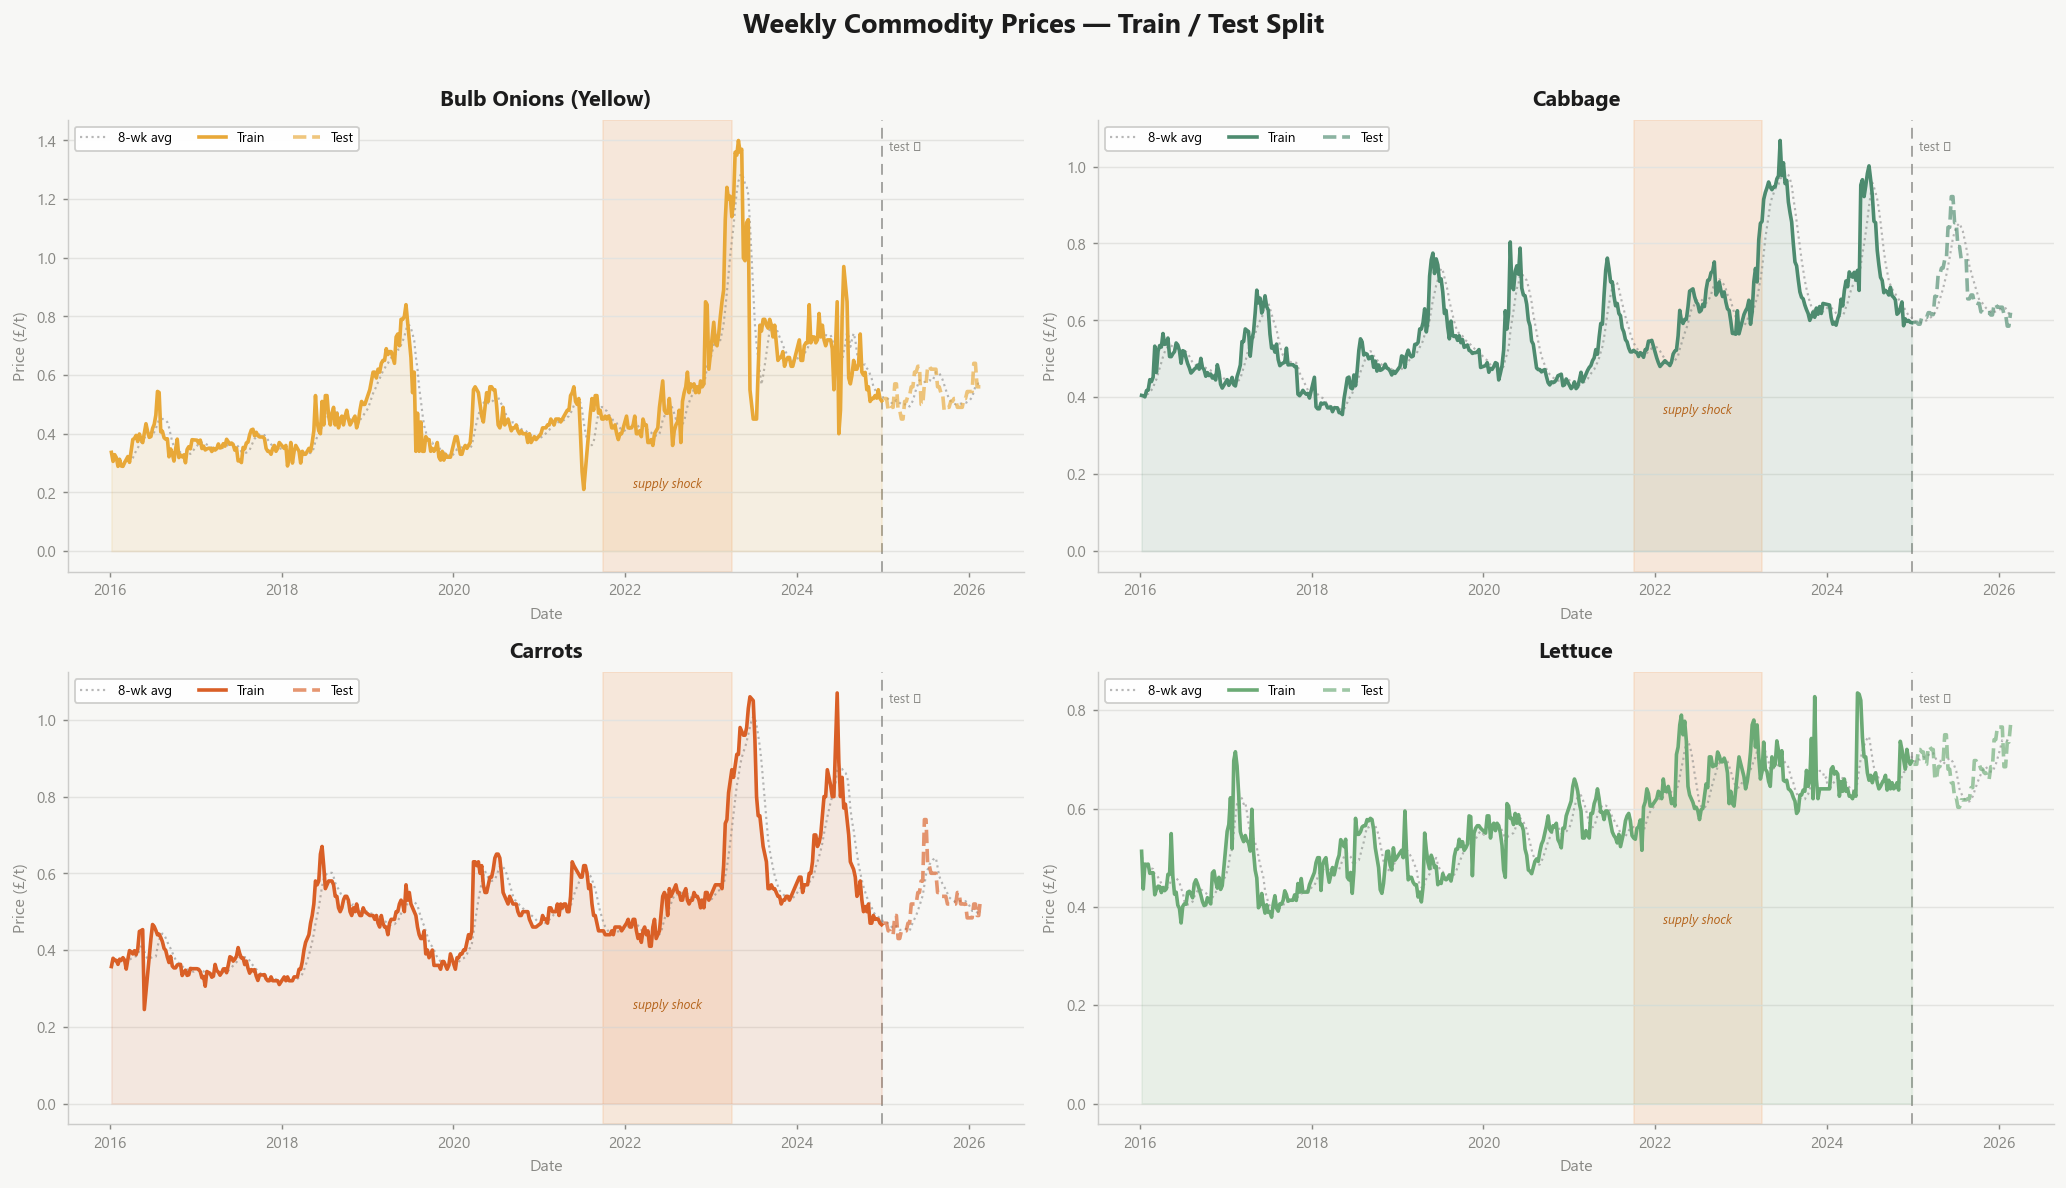

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), facecolor=BG)
fig.suptitle('Weekly Commodity Prices — Train / Test Split',
             fontsize=15, fontweight='bold', color=TEXT_COLOR, y=1.01)
for ax, comm in zip(axes.flat, COMMODITIES):
    plot_time_series(df, comm, ax=ax)
plt.tight_layout()
plt.savefig('../outputs/eda_01_time_series.png', bbox_inches='tight', facecolor=BG)
plt.show()

In [6]:
def _run_tests(series, label, commodity):
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    stationary = (adf_p < 0.05) and (kpss_p > 0.05)
    return {
        'Commodity':    commodity,
        'Series':       label,
        'ADF stat':     round(adf_stat,  3),
        'ADF p-value':  round(adf_p,     4),
        'KPSS stat':    round(kpss_stat, 3),
        'KPSS p-value': round(kpss_p,    4),
        'Stationary?':  'Yes' if stationary else 'No',
    }

def plot_stationarity_summary(df, commodities=None):
    if commodities is None:
        commodities = COMMODITIES
    rows = []
    for comm in commodities:
        sub = (df[(df['commodity'] == comm) & (df['split'] == 'train')]
               .sort_values('date').dropna(subset=['target_price']))
        s = sub['target_price'].values
        rows.append(_run_tests(s,          'Raw',      comm))
        rows.append(_run_tests(np.diff(s), '1st Diff', comm))
    results = pd.DataFrame(rows)

    col_order = ['Commodity', 'Series', 'ADF stat', 'ADF p-value',
                 'KPSS stat', 'KPSS p-value', 'Stationary?']
    cell_vals = results[col_order].values.tolist()

    fig, ax = plt.subplots(figsize=(14, 4.6), facecolor=BG)
    ax.set_facecolor(BG)
    ax.axis('off')
    fig.suptitle('Stationarity Tests: ADF & KPSS  (training set)',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, y=1.02)

    tbl = ax.table(cellText=cell_vals, colLabels=col_order,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)

    for j in range(len(col_order)):
        c = tbl[0, j]
        c.set_facecolor('#2C3E50')
        c.set_text_props(color='white', fontweight='bold')
        c.set_edgecolor('#3D5166')
        c.set_height(0.14)

    for i, row in enumerate(cell_vals):
        ri = i + 1
        adf_p_val  = float(row[3])
        kpss_p_val = float(row[5])
        stationary = row[6] == 'Yes'
        row_base   = '#F0F0EE' if i % 2 == 0 else '#FAFAF8'
        comm_color = COMMODITY_COLORS.get(str(row[0]), '#DDDDDD')
        for j in range(len(col_order)):
            cell = tbl[ri, j]
            cell.set_edgecolor('#E0E0DE')
            cell.set_height(0.12)
            if j == 0:
                cell.set_facecolor(comm_color + '33')
            elif j == 3:
                cell.set_facecolor('#D5EFDD' if adf_p_val < 0.05 else '#FAD7D7')
            elif j == 5:
                cell.set_facecolor('#D5EFDD' if kpss_p_val > 0.05 else '#FAD7D7')
            elif j == 6:
                cell.set_facecolor('#C8E6C9' if stationary else '#FFCDD2')
                cell.set_text_props(fontweight='bold',
                                    color='#2E7D32' if stationary else '#C62828')
            else:
                cell.set_facecolor(row_base)

    plt.tight_layout()
    plt.savefig('../outputs/eda_02_stationarity.png', bbox_inches='tight', facecolor=BG)
    plt.show()
    return fig, results

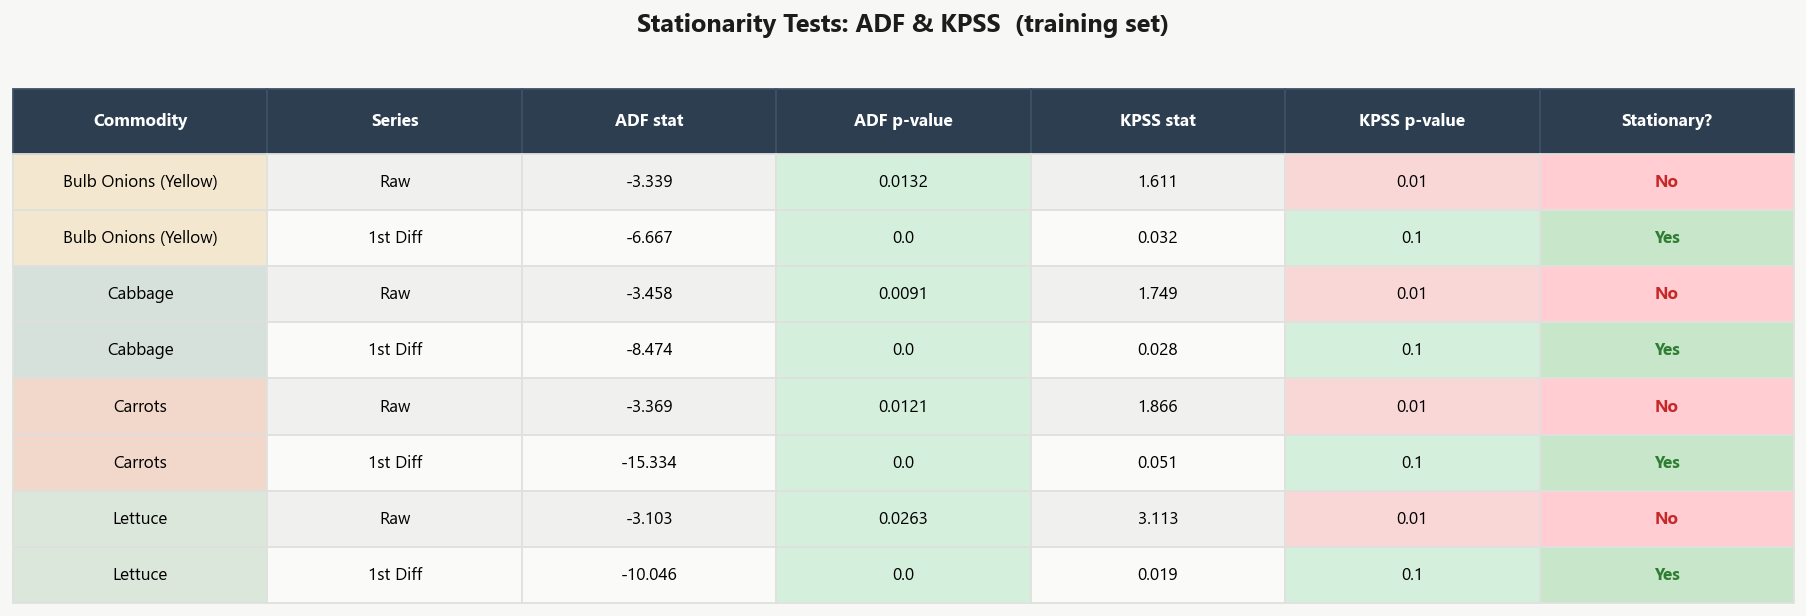

,Commodity,Series,ADF stat,ADF p-value,KPSS stat,KPSS p-value,Stationary?
0,Bulb Onions (Yellow),Raw,-3.339,0.0132,1.611,0.01,No
1,Bulb Onions (Yellow),1st Diff,-6.667,0.0000,0.032,0.10,Yes
2,Cabbage,Raw,-3.458,0.0091,1.749,0.01,No
3,Cabbage,1st Diff,-8.474,0.0000,0.028,0.10,Yes
4,Carrots,Raw,-3.369,0.0121,1.866,0.01,No
5,Carrots,1st Diff,-15.334,0.0000,0.051,0.10,Yes
6,Lettuce,Raw,-3.103,0.0263,3.113,0.01,No
7,Lettuce,1st Diff,-10.046,0.0000,0.019,0.10,Yes


In [7]:
fig_stat, stat_results = plot_stationarity_summary(df)
stat_results

In [8]:
def plot_acf_pacf(df, commodity, nlags=52, figsize=(14, 8)):
    sub = (df[(df['commodity'] == commodity) & (df['split'] == 'train')]
           .sort_values('date').dropna(subset=['target_price']))
    series = sub['target_price'].values
    diff_s = np.diff(series)
    color  = COMMODITY_COLORS[commodity]

    fig, axes = plt.subplots(2, 2, figsize=figsize, facecolor=BG)
    fig.suptitle(f'ACF & PACF  ——  {commodity}',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR, y=1.02)

    configs = [
        (series, plot_acf,  'ACF – Raw Series',       0, 0, {}),
        (series, plot_pacf, 'PACF – Raw Series',      0, 1, {'method': 'ywm'}),
        (diff_s, plot_acf,  'ACF – 1st Difference',   1, 0, {}),
        (diff_s, plot_pacf, 'PACF – 1st Difference',  1, 1, {'method': 'ywm'}),
    ]

    for s, fn, title, row, col, extra in configs:
        ax = axes[row, col]
        fn(s, lags=nlags, ax=ax, alpha=0.05, zero=False,
           color=color,
           vlines_kwargs={'colors': color, 'linewidth': 1.6},
           **extra)
        for coll in ax.collections:
            coll.set_facecolor('#CCCCCC')
            coll.set_alpha(0.25)
        ax.axhline(0, color=SPINE_COLOR, lw=0.9)
        _style_ax(ax)
        ax.set_title(title, fontsize=11, fontweight='semibold', color=TEXT_COLOR, pad=6)
        ax.set_xlabel('Lag (weeks)', fontsize=8.5)
        ax.set_ylabel('Correlation', fontsize=8.5)

    plt.tight_layout()
    safe = commodity.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'../outputs/eda_03_acf_pacf_{safe}.png', bbox_inches='tight', facecolor=BG)
    plt.show()
    return fig

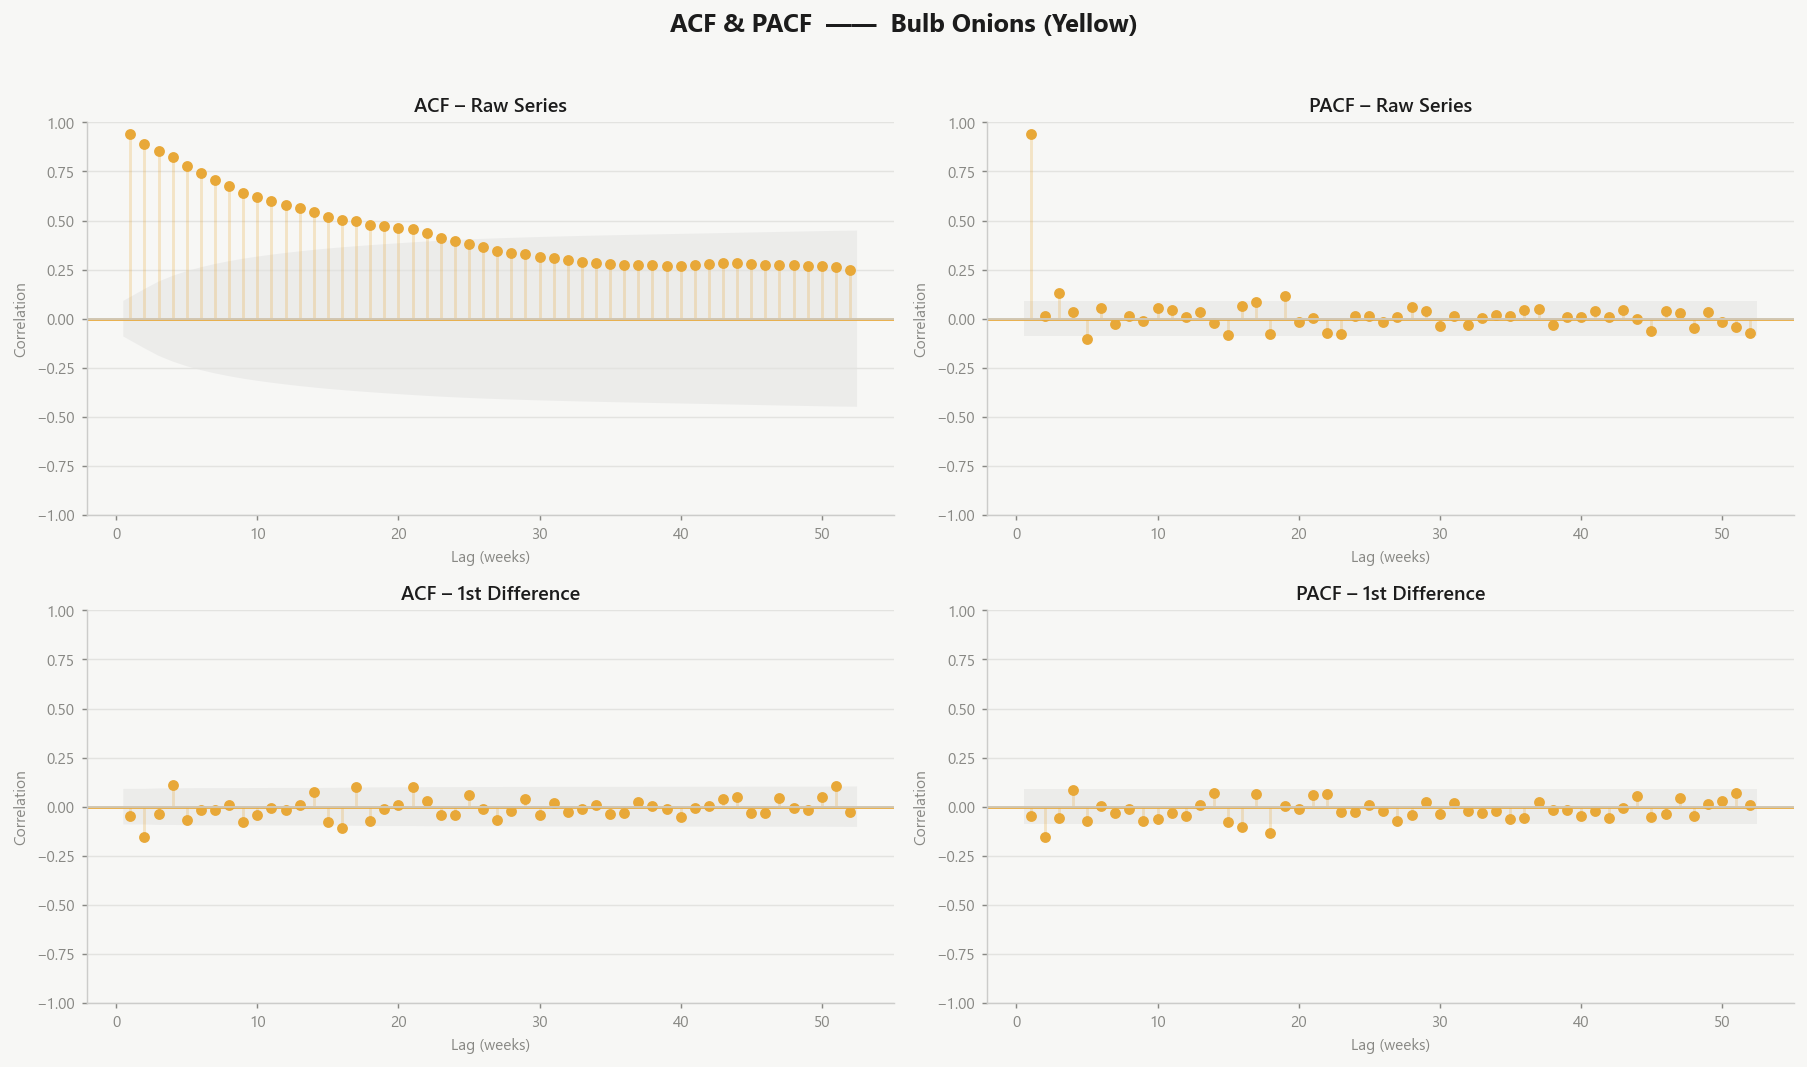

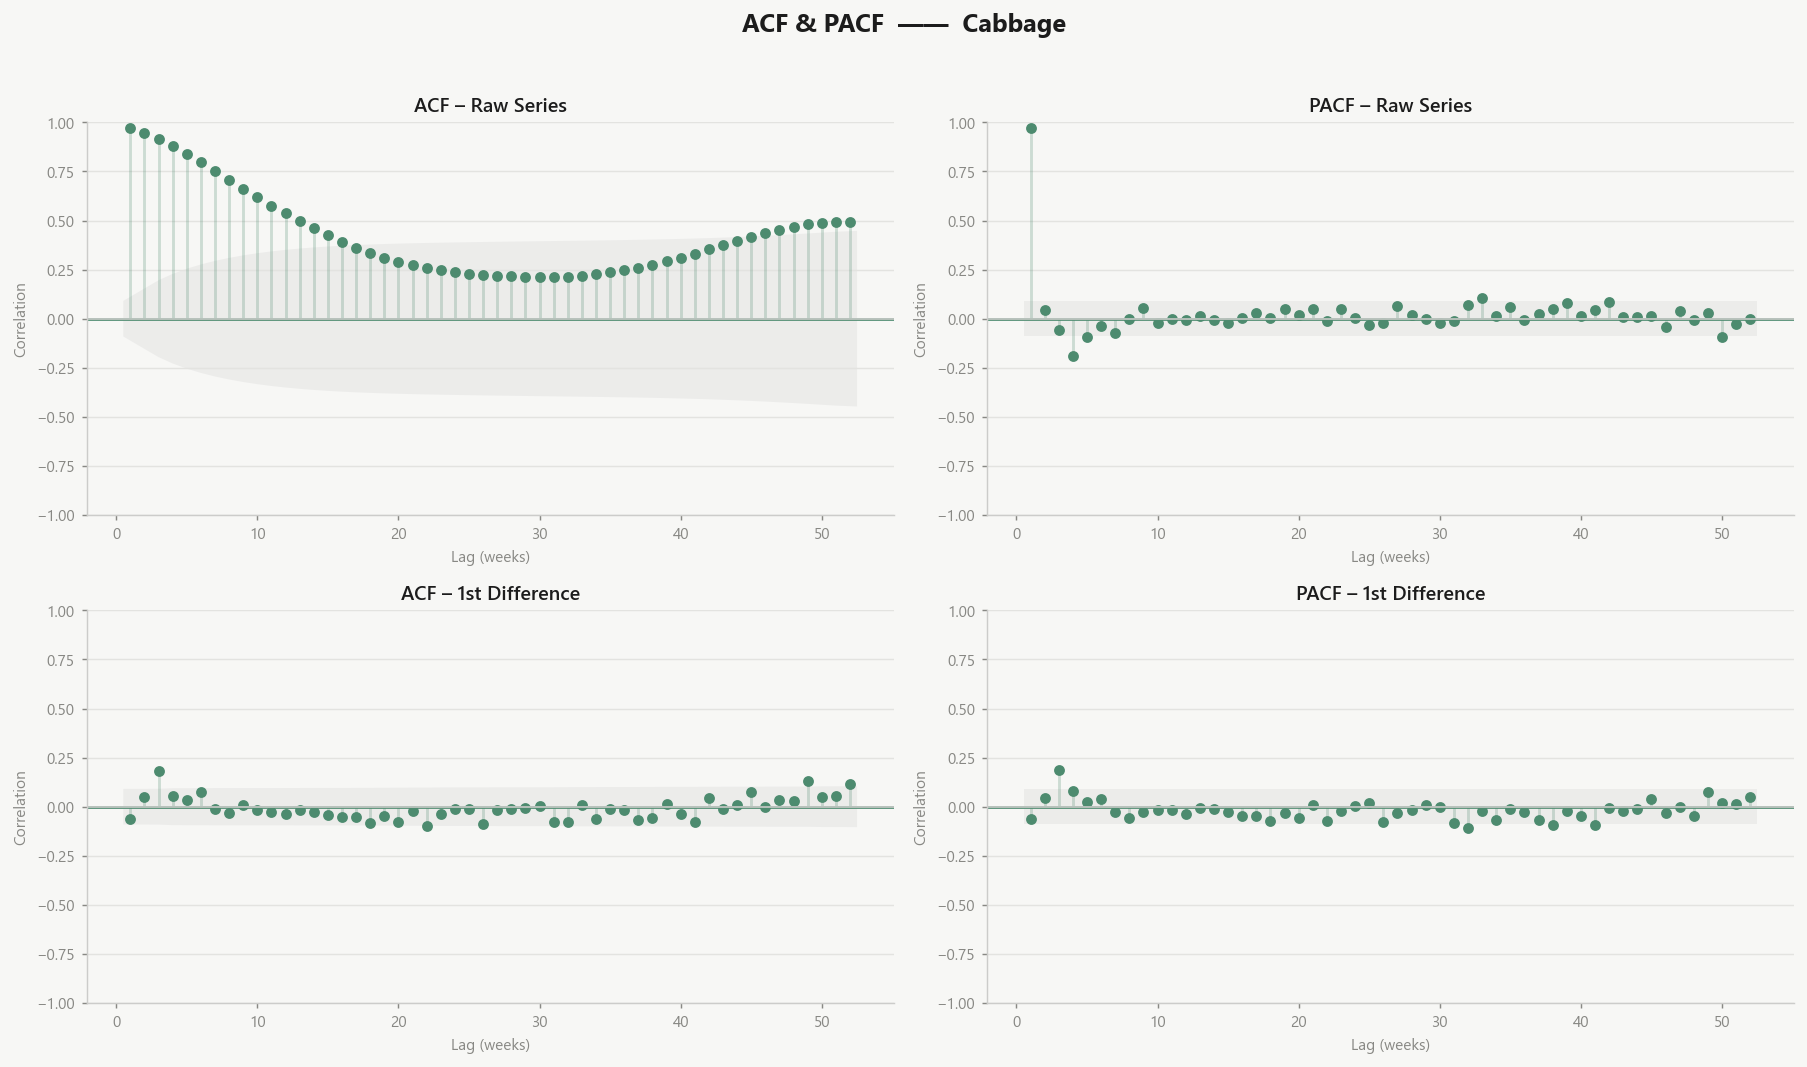

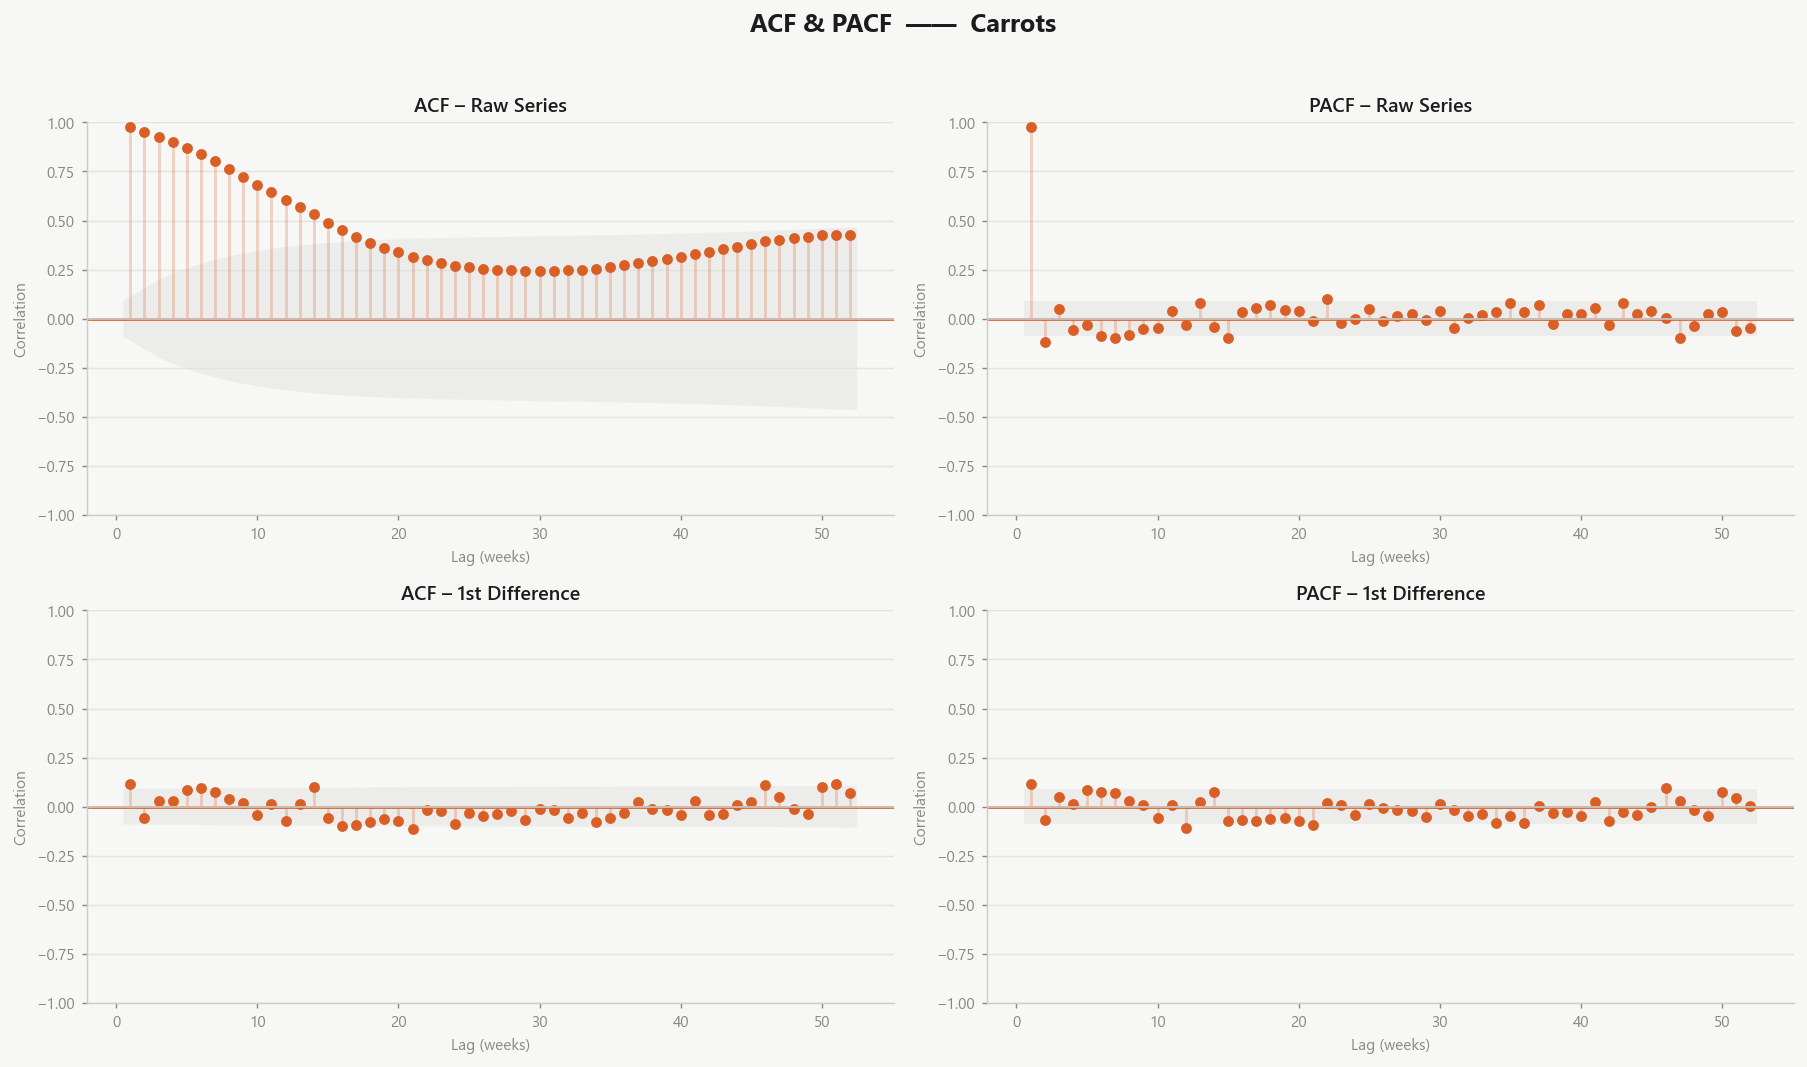

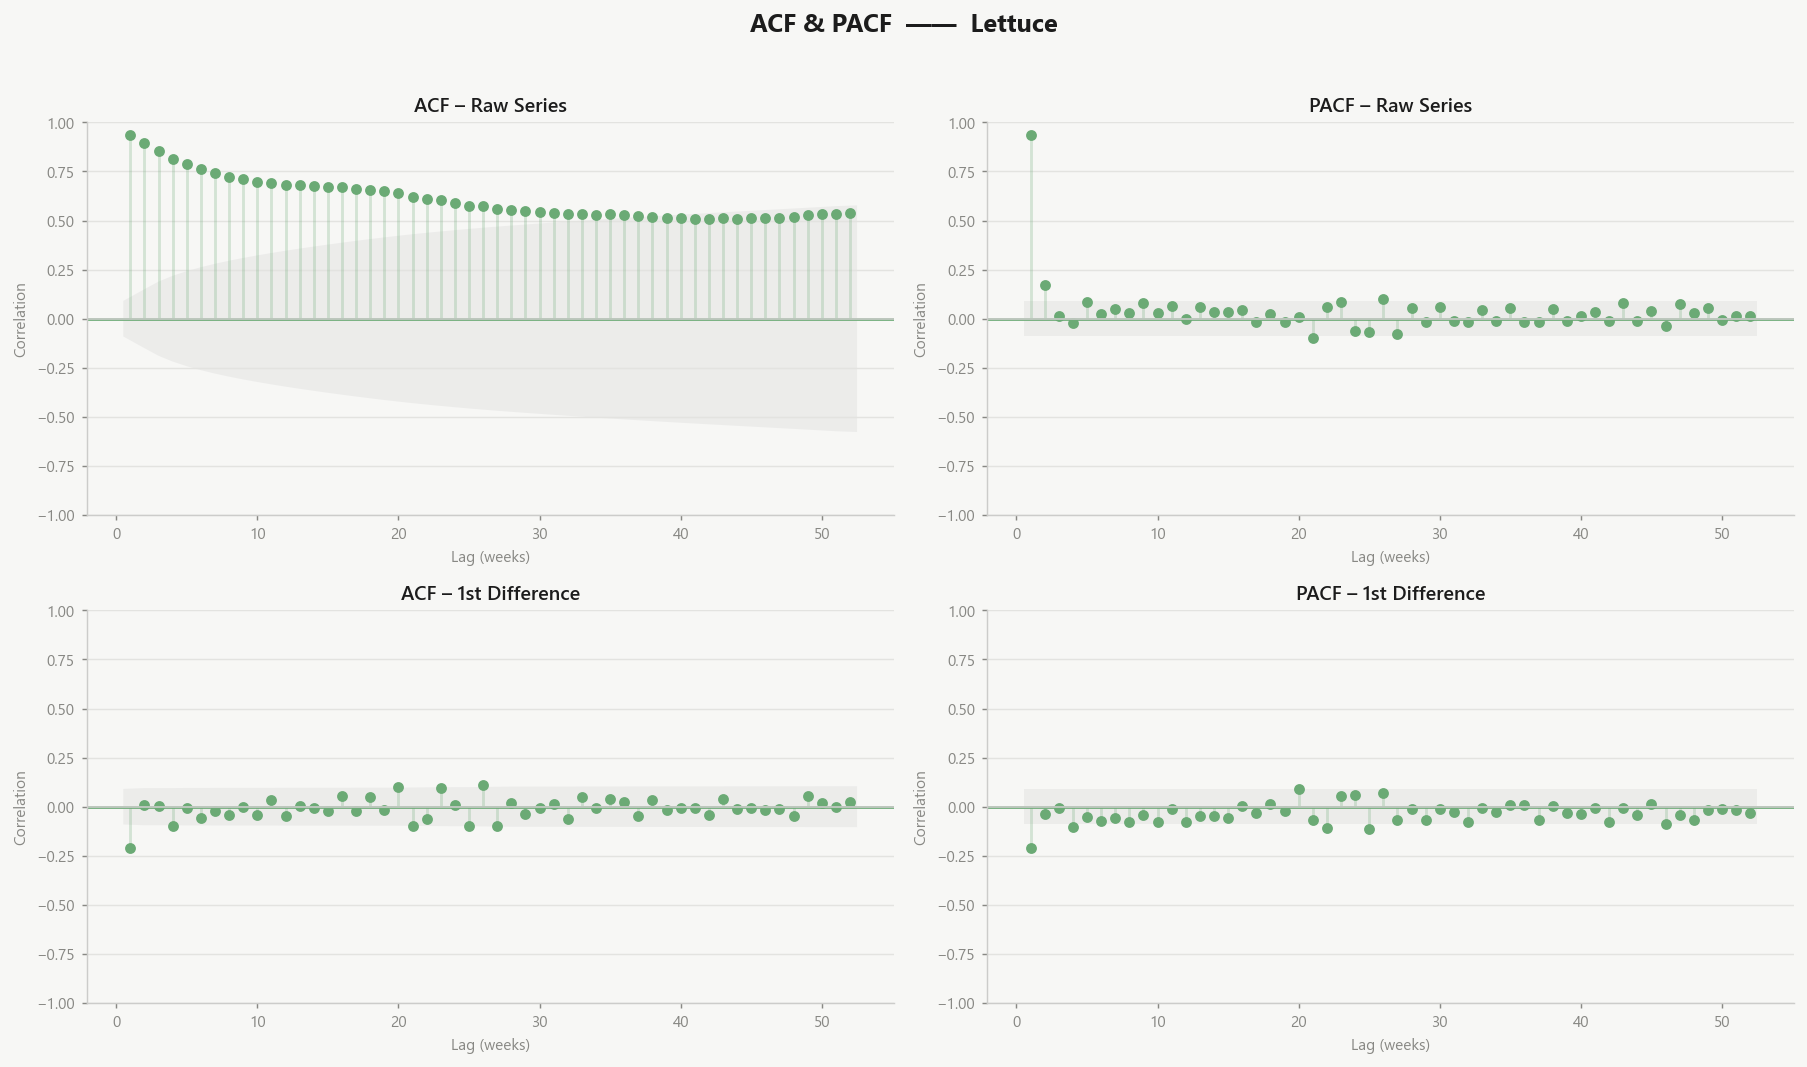

In [9]:
for comm in COMMODITIES:
    plot_acf_pacf(df, comm)

In [10]:
def plot_stl_decomposition(df, commodity, figsize=(13, 9)):
    sub = (df[(df['commodity'] == commodity) & (df['split'] == 'train')]
           .sort_values('date').dropna(subset=['target_price']))
    series = pd.Series(sub['target_price'].values,
                       index=pd.to_datetime(sub['date']))
    color = COMMODITY_COLORS[commodity]

    stl    = STL(series, period=FREQ, seasonal=13, robust=True)
    result = stl.fit()

    components = [
        ('Observed',  result.observed, color,      False),
        ('Trend',     result.trend,    '#2C3E50',   False),
        ('Seasonal',  result.seasonal, '#5B9BD5',   True),
        ('Residual',  result.resid,    MUTED,       True),
    ]

    fig = plt.figure(figsize=figsize, facecolor=BG)
    gs  = gridspec.GridSpec(4, 1, hspace=0.38, figure=fig)
    fig.suptitle(f'STL Decomposition  ——  {commodity}  (training set)',
                 fontsize=14, fontweight='bold', color=TEXT_COLOR)

    for i, (label, comp, c, fill) in enumerate(components):
        ax = fig.add_subplot(gs[i])
        ax.axvspan(SHOCK_START, SHOCK_END, color='#F4A261', alpha=0.15, zorder=0)
        ax.plot(comp.index, comp.values, color=c, lw=1.7, zorder=3)
        if fill:
            ax.fill_between(comp.index, comp.values, alpha=0.20, color=c, zorder=2)
        ax.axhline(0, color=SPINE_COLOR, lw=0.9, zorder=1)
        ax.spines['left'].set_color(c)
        ax.spines['left'].set_linewidth(2.5)
        ax.spines['bottom'].set_color(SPINE_COLOR)
        _style_ax(ax)
        ax.set_ylabel(label, fontsize=10, color=TEXT_COLOR, fontweight='semibold')
        if i < 3:
            ax.set_xticklabels([])
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Date', fontsize=9)

    plt.tight_layout()
    safe = commodity.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'../outputs/eda_04_stl_{safe}.png', bbox_inches='tight', facecolor=BG)
    plt.show()
    return fig

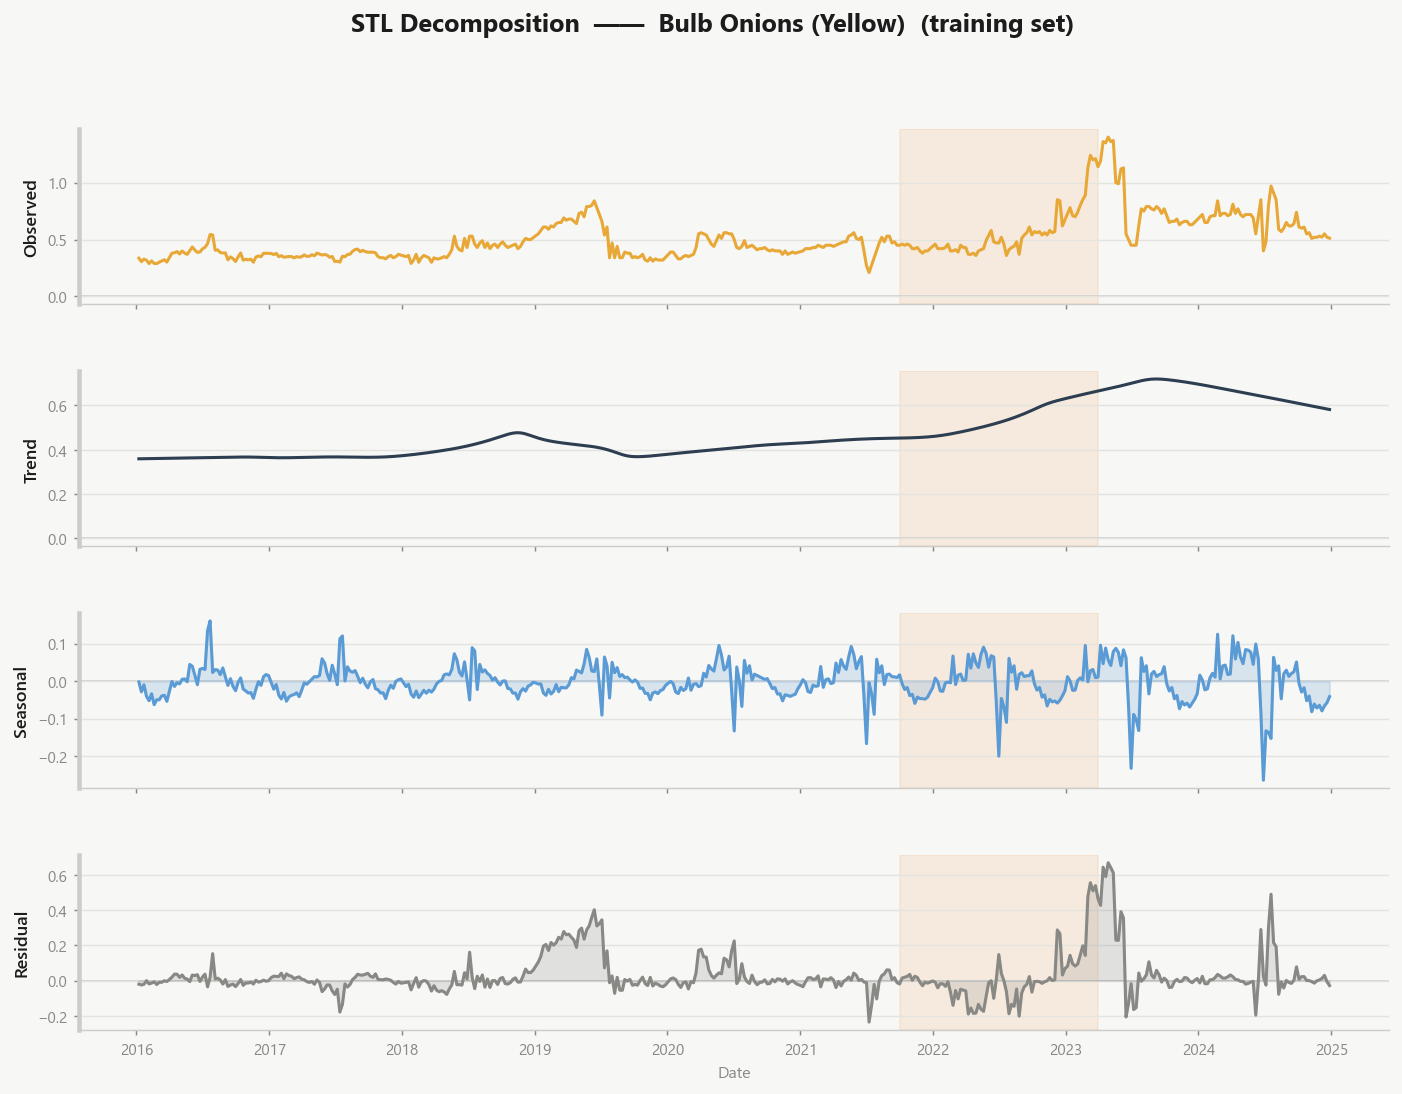

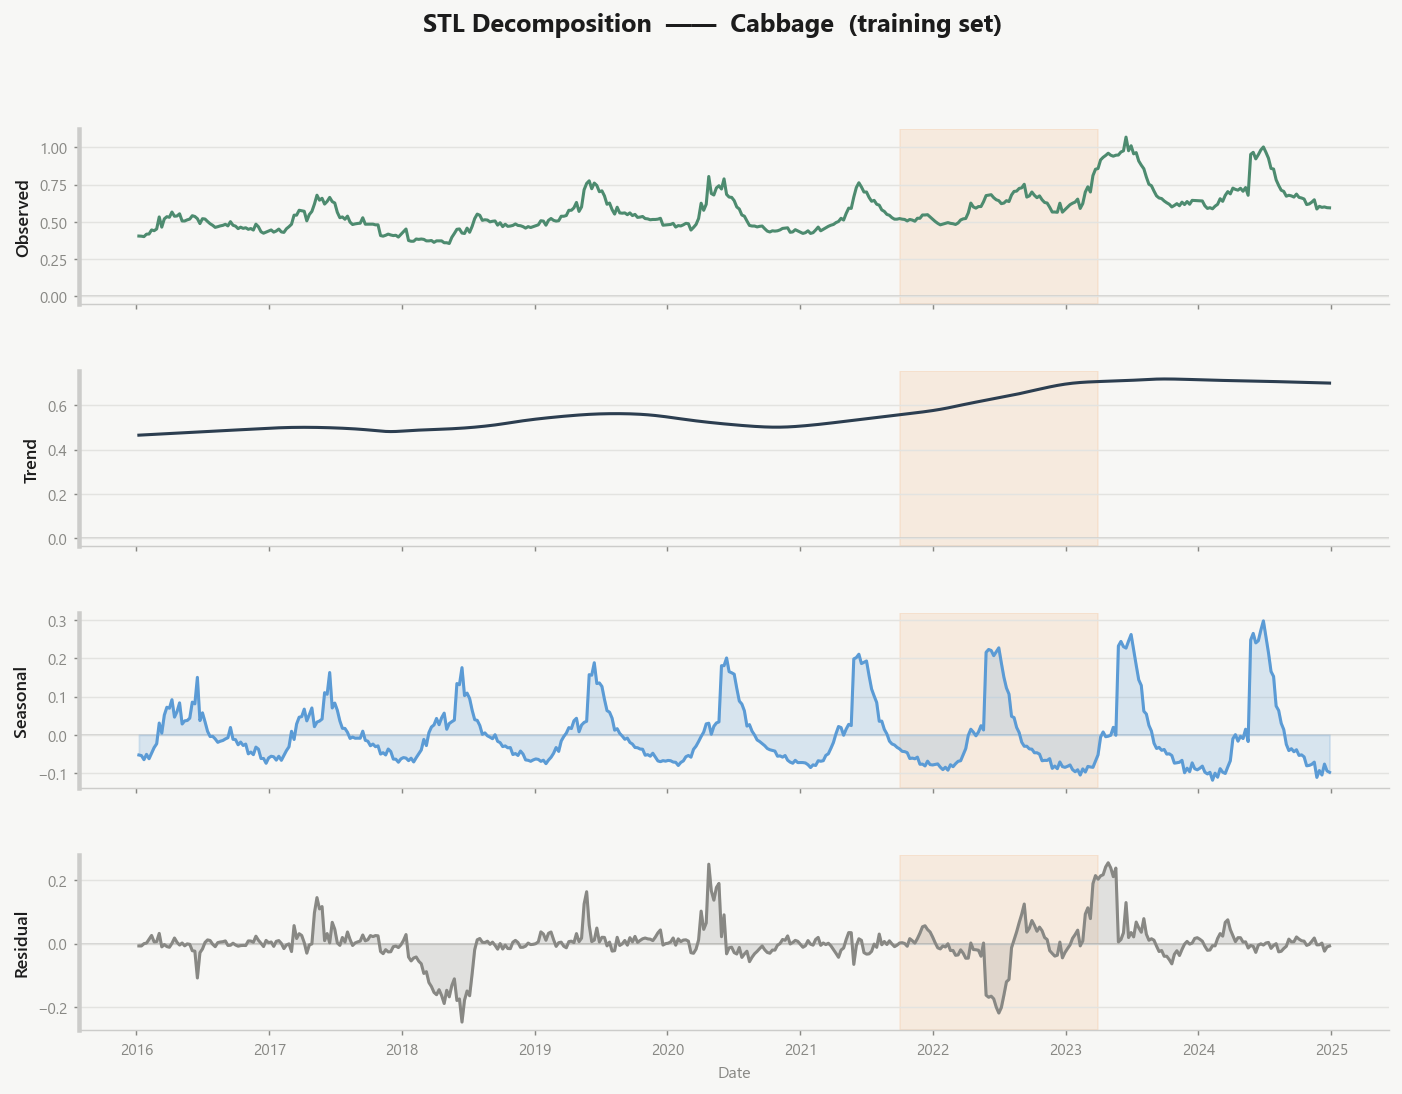

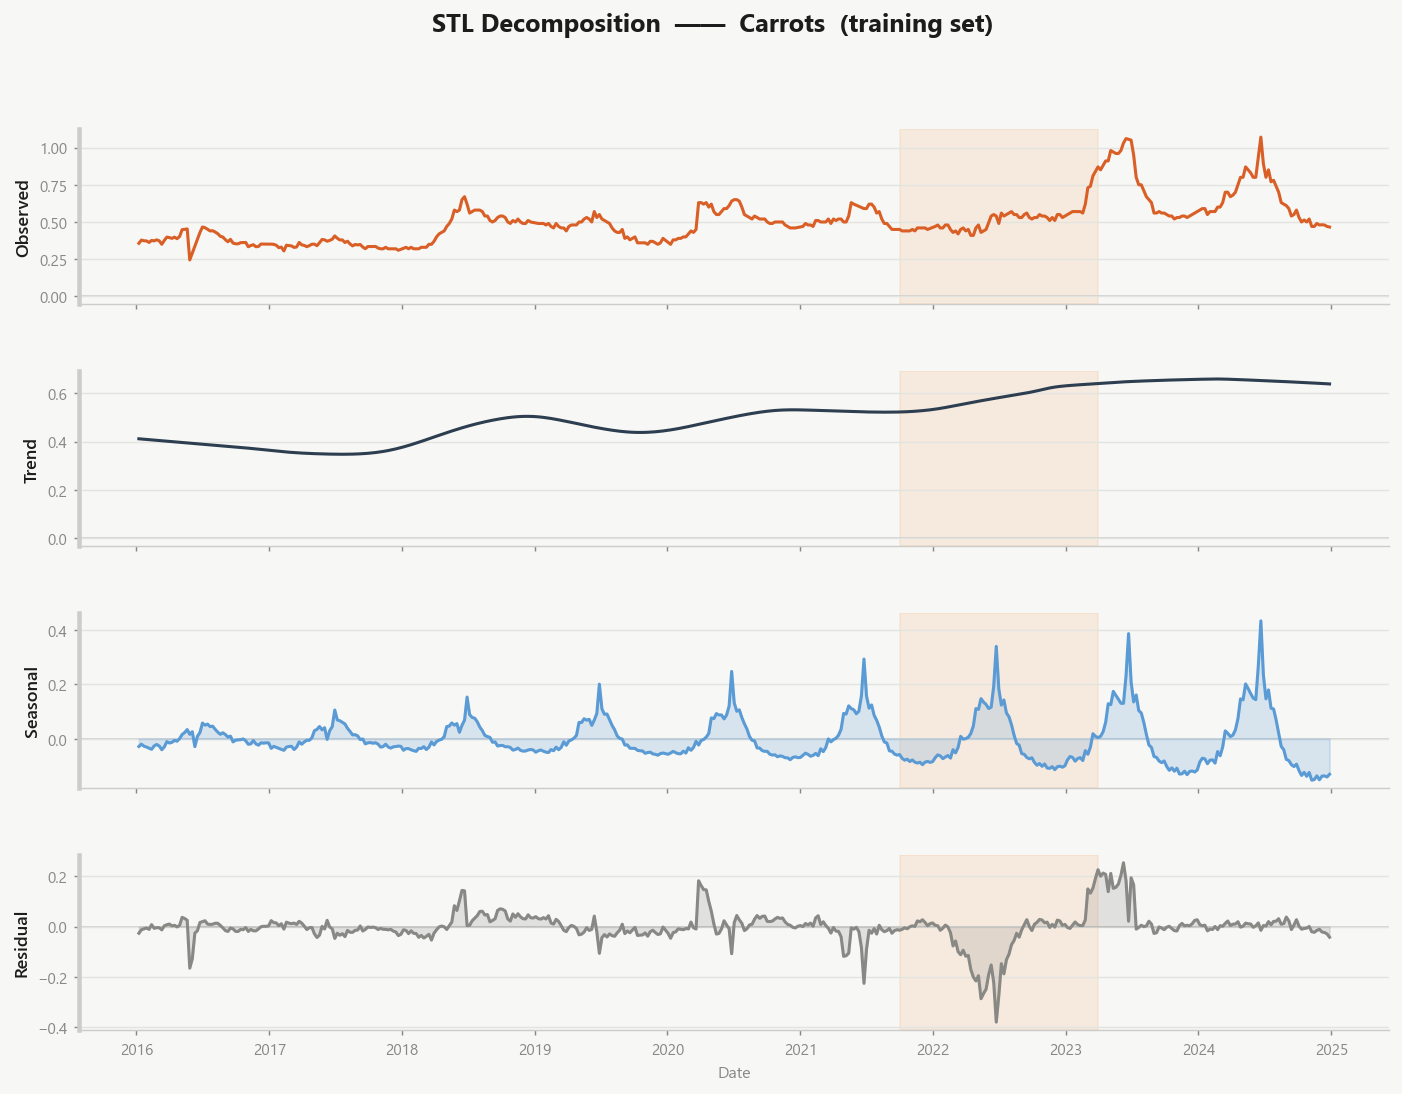

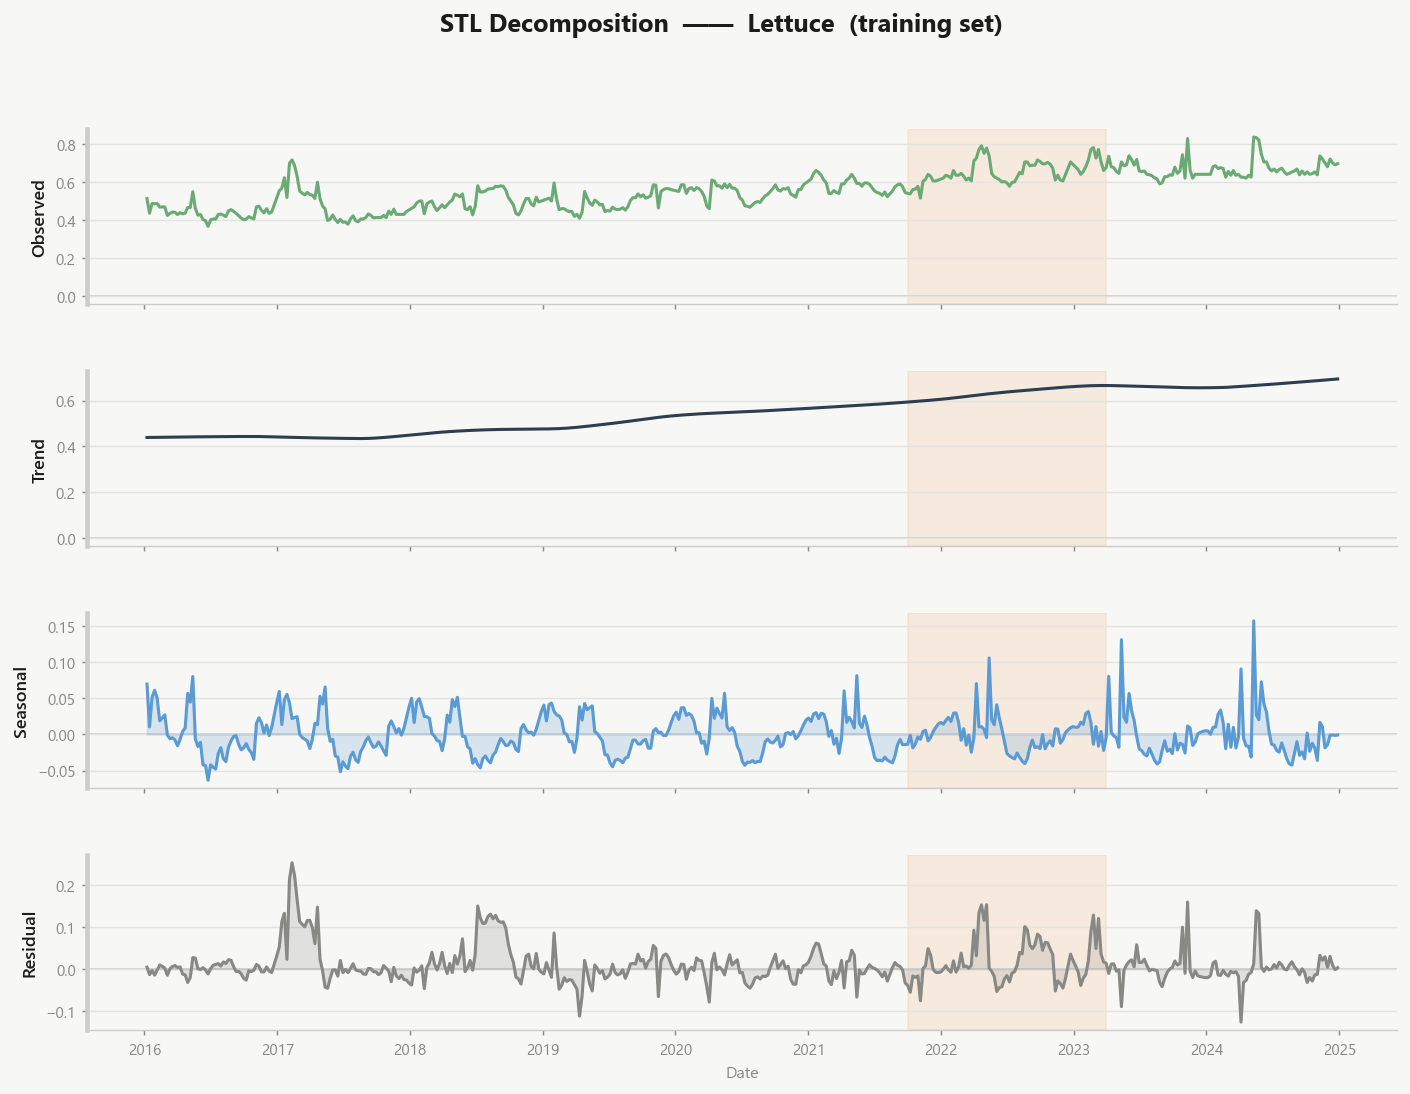

In [11]:
for comm in COMMODITIES:
    plot_stl_decomposition(df, comm)